# 02 - Splitting

In diesem Notebook wird ein **streng chronologischer** 70/15/15-Split auf `data/processed/features.csv` durchgeführt und als CSV exportiert.

Warum chronologisch? Bei Zeitreihen würde ein zufälliger Split zu Data Leakage führen, weil Informationen aus der Zukunft indirekt ins Training gelangen könnten.

Die Splits sind daher bewusst als **Train (Vergangenheit) -> Validation (später) -> Test (jüngster Zeitraum)** definiert.

In [17]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

TARGET = 'Solarproduktion'
DATA_PATH = Path('../data/processed/features.csv')
OUT_DIR = Path('../data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEASON_MAP = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
SEASON_ORDER = ['Winter', 'Spring', 'Summer', 'Autumn']


In [18]:
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

n = len(df)
val_start = int(n * 0.70)
test_start = int(n * 0.85)

train = df.iloc[:val_start].copy()
val = df.iloc[val_start:test_start].copy()
test = df.iloc[test_start:].copy()

print(f'Train: {len(train):,} rows')
print(f'Val  : {len(val):,} rows')
print(f'Test : {len(test):,} rows')


Train: 82,342 rows
Val  : 17,645 rows
Test : 17,645 rows


## Visualisierung des Splits über den gesamten Zeitraum

Die folgenden Punkte zeigen `Solarproduktion` über die Zeit, farblich codiert nach Split: **Train (blau)**, **Validation (orange)**, **Test (grün)**.

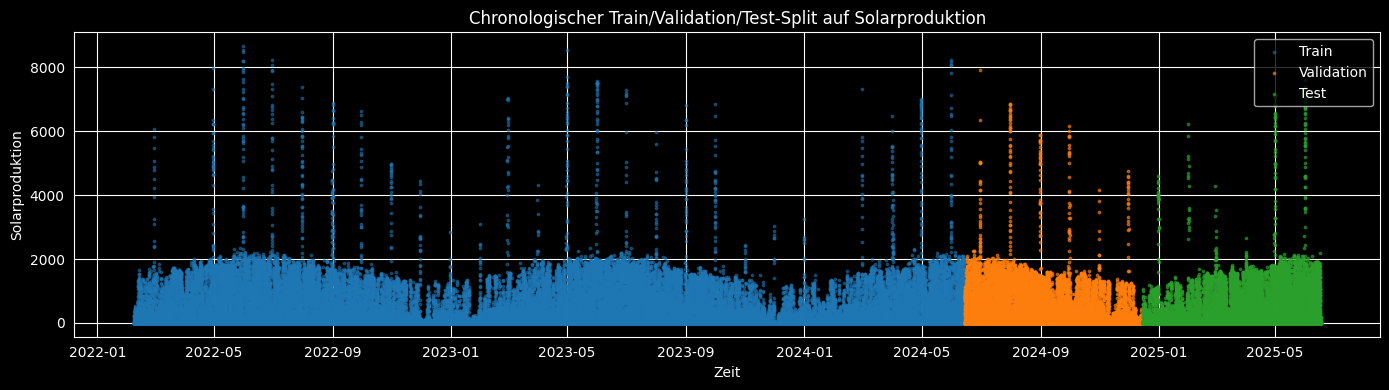

In [19]:
plt.figure(figsize=(14, 4))
plt.scatter(train['timestamp'], train[TARGET], s=3, alpha=0.5, label='Train', c='tab:blue')
plt.scatter(val['timestamp'], val[TARGET], s=3, alpha=0.6, label='Validation', c='tab:orange')
plt.scatter(test['timestamp'], test[TARGET], s=3, alpha=0.6, label='Test', c='tab:green')
plt.title('Chronologischer Train/Validation/Test-Split auf Solarproduktion')
plt.xlabel('Zeit')
plt.ylabel(TARGET)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [20]:
def split_summary(train_df, val_df, test_df):
    total = len(train_df) + len(val_df) + len(test_df)
    rows = []
    for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        rows.append({
            'split': name,
            'from': split_df['timestamp'].min(),
            'to': split_df['timestamp'].max(),
            'n': len(split_df),
            'share': f"{len(split_df)/total:.1%}",
        })
    return pd.DataFrame(rows).set_index('split')

def split_season_distribution(train_df, val_df, test_df):
    rows = {}
    for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        seasons = split_df['timestamp'].dt.month.map(SEASON_MAP)
        counts = seasons.value_counts(normalize=True).reindex(SEASON_ORDER, fill_value=0.0)
        rows[name] = counts.round(3)
    return pd.DataFrame(rows).T

split_summary(train, val, test)


,from,to,n,share
split,,,,
train,2022-02-07 15:00:00,2024-06-14 09:15:00,82342,70.0%
val,2024-06-14 09:30:00,2024-12-15 04:30:00,17645,15.0%
test,2024-12-15 04:45:00,2025-06-16 23:45:00,17645,15.0%


In [21]:
split_season_distribution(train, val, test)

timestamp,Winter,Spring,Summer,Autumn
train,0.236,0.322,0.230,0.212
val,0.077,0.000,0.428,0.495
test,0.412,0.501,0.087,0.000


In [22]:
train.to_csv(OUT_DIR / 'train.csv', index=False)
val.to_csv(OUT_DIR / 'val.csv', index=False)
test.to_csv(OUT_DIR / 'test.csv', index=False)

print('Saved:', OUT_DIR / 'train.csv')
print('Saved:', OUT_DIR / 'val.csv')
print('Saved:', OUT_DIR / 'test.csv')


Saved: ../data/processed/train.csv
Saved: ../data/processed/val.csv
Saved: ../data/processed/test.csv
